# Geodesical Motion in 3D Kerr Space-Time
<it>Scripts for plotting parameter spaces and trajectories relating to Kerr Space Time</it>

Acknowledgement of AI Use - The use of generative AI was made for creating certain parts of this plotting script. Specifically - some plot elements of Figure 4 and the calculation of the elliptic function of third kind in Figure 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

from mpl_toolkits.mplot3d import Axes3D
from scipy.special import ellipj, ellipk
from scipy.integrate import cumulative_trapezoid

In [2]:
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["STIXTwoText", "DejaVu Serif", "Times New Roman"],
    "mathtext.fontset":   "stix",
    "axes.linewidth":     0.8,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   5,
    "ytick.major.size":   5,
    "xtick.minor.size":   3,
    "ytick.minor.size":   3,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top":          True,
    "ytick.right":        True,
})


BG      = "#F7F5F0"         
COL_TEAL  = "#1A5F7A"         
COL_ROSE  = "#8B3A3A"          
COL_LBLUE  = "#C8D8E4"          
COL_CHARC  = "#4A4A4A"          
COL_GOLD = "#7A6A2A"          
COL_GREY = "#999999"          
COL_BBLUE  = "#66CCEE"
COL_TEALV2 = "#003f5c"
COL_VIOLET = "#58508d"
COL_PINK = "#bc5090"
COL_BRICK = "#ff6361"
COL_YELLOW = "#ffa600"

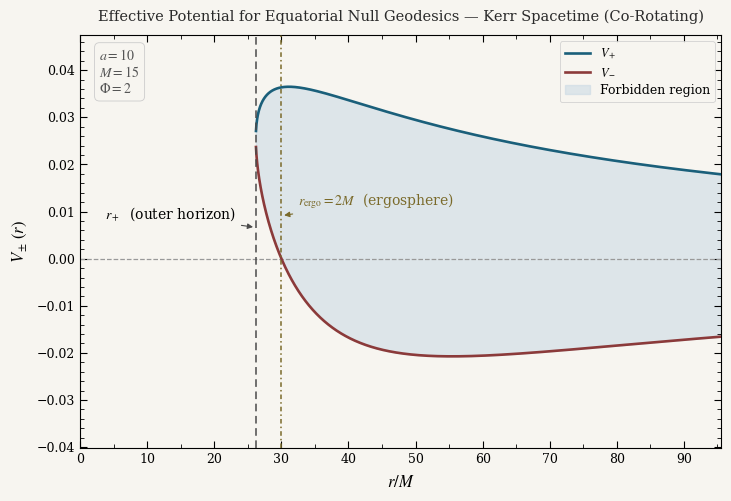

In [3]:
# Parameters for the Black Hole and Particle Trajectories
a = 10
L = 2
M = 15

# Finding the event horizon position and the ergosphere boundary in the equatorial plane
deltaCoeffs = np.array([1.0, -2*M, a**2])
deltaRoots  = np.roots(deltaCoeffs)
deltaRoots  = np.sort(deltaRoots)

r_plus      = deltaRoots[1]          
r_ergo      = 2 * M                  

graphLimit = r_plus*3.65

r = np.linspace(r_plus * 1.001, graphLimit, 2000)

delta  = r**2 - 2*M*r + a**2
denom  = (r**2 + a**2)**2 - a**2 * delta

Vplus  = (2*M*L*a*r + np.abs(L)*r**2*np.sqrt(np.maximum(delta, 0))) / denom
Vminus = (2*M*L*a*r - np.abs(L)*r**2*np.sqrt(np.maximum(delta, 0))) / denom


# PLOTTING
fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor=BG)
ax.set_title(
    r"Effective Potential for Equatorial Null Geodesics — Kerr Spacetime (Co-Rotating)",
    fontsize=10.5, pad=10, color="#2A2A2A"
)
ax.set_facecolor(BG)

# ── Potential curves ──────────────────────────────────────────────────────────
ax.plot(r, Vplus,  color=COL_TEAL, lw=1.9, label=r"$V_+$",  zorder=3)
ax.plot(r, Vminus, color=COL_ROSE, lw=1.9, label=r"$V_-$",  zorder=3)

# ── Zero line ─────────────────────────────────────────────────────────────────
ax.axhline(y=0, color=COL_GREY, lw=0.9, ls="--", zorder=2)

# Event Horizon 
ax.axvline(x=r_plus, color=COL_CHARC, lw=1.1, ls=(0, (5, 3)), zorder=4)

ax.annotate(
    r"$r_+$  (outer horizon)",
    xy=(r_plus, np.max(Vplus)/5.5),
    xytext=(r_plus - 22.5, np.max(Vplus)/5),
    fontsize=10, color="black",
    arrowprops=dict(arrowstyle="-|>", color=COL_CHARC,
                    lw=0.8, mutation_scale=8),
    ha="left", va="bottom",
)

# Ergosphere Boundary
ax.axvline(x=r_ergo, color=COL_GOLD, lw=1.1, ls=(0, (3, 2, 1, 2)), zorder=4)

ax.annotate(
    r"$r_\mathrm{ergo} = 2M$  (ergosphere)",
    xy=(r_ergo, np.max(Vplus)/4.0),
    xytext=(r_ergo + 2.5, np.max(Vplus)/3.0),
    fontsize=10, color=COL_GOLD,
    arrowprops=dict(arrowstyle="-|>", color=COL_GOLD,
                    lw=0.8, mutation_scale=8),
    ha="left", va="center",
)

# Shading unallowed region
mask = (r >= r_plus) & (r <= graphLimit)
ax.fill_between(r[mask], Vminus[mask], Vplus[mask],
                where=(Vplus[mask] >= Vminus[mask]),
                color=COL_LBLUE, alpha=0.55,
                label="Forbidden region", zorder=1)


ax.set_xlim(0, graphLimit)
ax.set_ylim(-np.max(Vplus)*1.1, np.max(Vplus)*1.3)

ax.set_xlabel(r"$r / M$",      fontsize=12, labelpad=6)
ax.set_ylabel(r"$V_\pm\,(r)$", fontsize=12, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(np.around(graphLimit/50, decimals=0)*5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.around(graphLimit/150, decimals=0)*5))

ax.tick_params(labelsize=9)

legend = ax.legend(
    fontsize=9, framealpha=0.85, edgecolor="#CCCCCC",
    facecolor=BG, loc="upper right",
    handlelength=2.0, labelspacing=0.4,
)
legend.get_frame().set_linewidth(0.6)

param_text = (
    rf"$a = {a}$" "\n" rf"$M = {M}$" "\n"
    rf"$\Phi = {L}$"
)
ax.text(0.03, 0.97, param_text,
        transform=ax.transAxes, fontsize=10.0,
        va="top", ha="left", color="#555555",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=BG,
                  edgecolor="#CCCCCC", linewidth=0.6))


plt.tight_layout(pad=1.4)
plt.savefig("../report/figures/kerr_potential_corrotating.png",
            dpi=300, bbox_inches="tight", facecolor=BG)

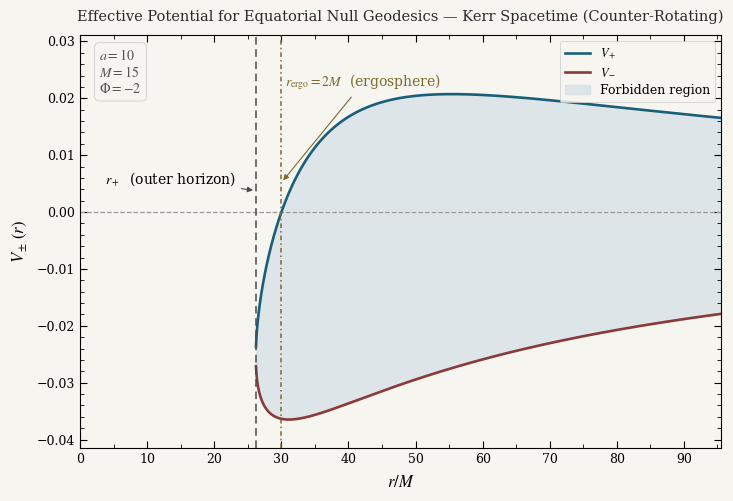

In [4]:
# Parameters for the Black Hole and Particle Trajectories
a = 10
L = -2
M = 15

# Finding the event horizon position and the ergosphere boundary in the equatorial plane
deltaCoeffs = np.array([1.0, -2*M, a**2])
deltaRoots  = np.roots(deltaCoeffs)
deltaRoots  = np.sort(deltaRoots)

r_plus      = deltaRoots[1]          
r_ergo      = 2 * M                  

graphLimit = r_plus*3.65

r = np.linspace(r_plus * 1.001, graphLimit, 2000)

delta  = r**2 - 2*M*r + a**2
denom  = (r**2 + a**2)**2 - a**2 * delta

Vplus  = (2*M*L*a*r + np.abs(L)*r**2*np.sqrt(np.maximum(delta, 0))) / denom
Vminus = (2*M*L*a*r - np.abs(L)*r**2*np.sqrt(np.maximum(delta, 0))) / denom


# PLOTTING
fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor=BG)
ax.set_title(
    r"Effective Potential for Equatorial Null Geodesics — Kerr Spacetime (Counter-Rotating)",
    fontsize=10.5, pad=10, color="#2A2A2A"
)
ax.set_facecolor(BG)

# ── Potential curves ──────────────────────────────────────────────────────────
ax.plot(r, Vplus,  color=COL_TEAL, lw=1.9, label=r"$V_+$",  zorder=3)
ax.plot(r, Vminus, color=COL_ROSE, lw=1.9, label=r"$V_-$",  zorder=3)

# ── Zero line ─────────────────────────────────────────────────────────────────
ax.axhline(y=0, color=COL_GREY, lw=0.9, ls="--", zorder=2)

# Event Horizon 
ax.axvline(x=r_plus, color=COL_CHARC, lw=1.1, ls=(0, (5, 3)), zorder=4)

ax.annotate(
    r"$r_+$  (outer horizon)",
    xy=(r_plus, np.max(Vplus)/5.5),
    xytext=(r_plus - 22.5, np.max(Vplus)/5),
    fontsize=10, color="black",
    arrowprops=dict(arrowstyle="-|>", color=COL_CHARC,
                    lw=0.8, mutation_scale=8),
    ha="left", va="bottom",
)

# Ergosphere Boundary
ax.axvline(x=r_ergo, color=COL_GOLD, lw=1.1, ls=(0, (3, 2, 1, 2)), zorder=4)

ax.annotate(
    r"$r_\mathrm{ergo} = 2M$  (ergosphere)",
    xy=(r_ergo, np.max(Vplus)/4.0),
    xytext=(r_ergo + 0.6, np.max(Vplus)*1.1),
    fontsize=10, color=COL_GOLD,
    arrowprops=dict(arrowstyle="-|>", color=COL_GOLD,
                    lw=0.8, mutation_scale=8),
    ha="left", va="center",
)

# Shading unallowed region
mask = (r >= r_plus) & (r <= graphLimit)
ax.fill_between(r[mask], Vminus[mask], Vplus[mask],
                where=(Vplus[mask] >= Vminus[mask]),
                color=COL_LBLUE, alpha=0.55,
                label="Forbidden region", zorder=1)


ax.set_xlim(0, graphLimit)
ax.set_ylim(-np.max(Vplus)*2.0, np.max(Vplus)*1.5)

ax.set_xlabel(r"$r / M$",      fontsize=12, labelpad=6)
ax.set_ylabel(r"$V_\pm\,(r)$", fontsize=12, labelpad=6)

ax.xaxis.set_major_locator(ticker.MultipleLocator(np.around(graphLimit/50, decimals=0)*5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.around(graphLimit/150, decimals=0)*5))

ax.tick_params(labelsize=9)

legend = ax.legend(
    fontsize=9, framealpha=0.85, edgecolor="#CCCCCC",
    facecolor=BG, loc="upper right",
    handlelength=2.0, labelspacing=0.4,
)
legend.get_frame().set_linewidth(0.6)

param_text = (
    rf"$a = {a}$" "\n" rf"$M = {M}$" "\n"
    rf"$\Phi = {L}$"
)
ax.text(0.03, 0.97, param_text,
        transform=ax.transAxes, fontsize=10.0,
        va="top", ha="left", color="#555555",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=BG,
                  edgecolor="#CCCCCC", linewidth=0.6))


plt.tight_layout(pad=1.4)
plt.savefig("../report/figures/kerr_potential_counterrotating.png",
            dpi=300, bbox_inches="tight", facecolor=BG)

/var/folders/07/rf8spkvs2qz4pts8tyq0b9xm0000gn/T/ipykernel_81338/209402559.py:15: RuntimeWarning: invalid value encountered in sqrt
  u0 = np.sqrt(((a**2 - Q - Phi**2) + np.sqrt((a**2 - Q - Phi**2)**2 + 4*a**2*Q)) / (2*a**2))
/var/folders/07/rf8spkvs2qz4pts8tyq0b9xm0000gn/T/ipykernel_81338/209402559.py:16: RuntimeWarning: invalid value encountered in sqrt
  u1 = np.sqrt(r**3 * (3*M - r) / (a**2*(r + M)))


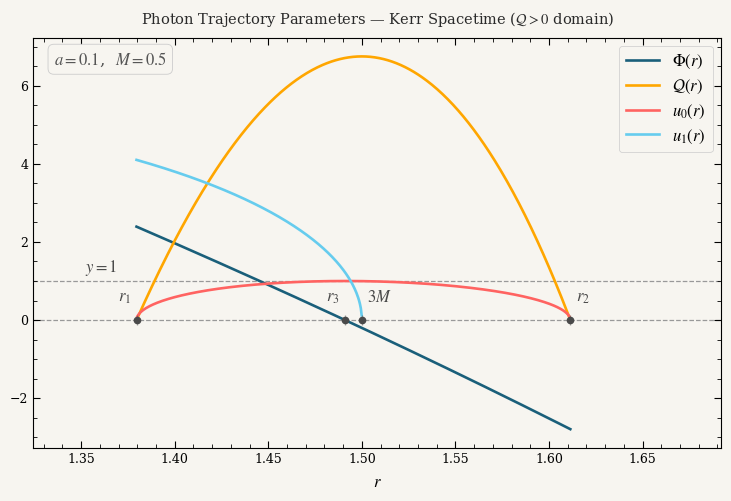

In [5]:
# Parameters
a = 0.1
M = 0.5

# Critical Radii
r1 = 2*M*(1 + np.cos((2/3)*np.arccos(-np.abs(a)/M)))
r2 = 2*M*(1 + np.cos((2/3)*np.arccos( np.abs(a)/M)))
r3 = M + 2*np.sqrt(M**2 - a**2/3) * np.cos((1/3) * np.arccos(M * (M**2 - a**2) / (M**2 - a**2/3)**(3/2)))

r = np.linspace(r1, r2, 500)

# Derived Quantities
Phi   = -(r**3 - 3*M*r**2 + a**2*r + a**2*M) / (a*(r - M))
Q     = -r**3 * (r**3 - 6*M*r**2 + 9*M**2*r - 4*a**2*M) / (a**2*(r - M)**2)
u0 = np.sqrt(((a**2 - Q - Phi**2) + np.sqrt((a**2 - Q - Phi**2)**2 + 4*a**2*Q)) / (2*a**2))
u1 = np.sqrt(r**3 * (3*M - r) / (a**2*(r + M)))

fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor=BG)
ax.set_facecolor(BG)
ax.set_title(
    r"Photon Trajectory Parameters — Kerr Spacetime ($\mathcal{Q}>0$ domain)",
    fontsize=10.5, pad=10, color="#2A2A2A"
)


ax.axhline(y=0, color="#999999", lw=0.9, ls="--", zorder=1)
ax.axhline(y=1, color="#999999", lw=0.9, ls="--", zorder=1)

ax.annotate(r"$y=1$", xy=(r1*0.98, 1.08),
                fontsize=12, color=COL_CHARC,
                ha="left", va="bottom")

# PLOTTING
ax.plot(r, Phi,   color=COL_TEAL, lw=1.9, label=r"$\Phi(r)$",        zorder=3)
ax.plot(r, Q,     color=COL_YELLOW,   lw=1.9, label=r"$\mathcal{Q}(r)$", zorder=3)
ax.plot(r, u0, color=COL_BRICK,  lw=1.9, label=r"$u_0(r)$",         zorder=3)
ax.plot(r, u1, color=COL_BBLUE,  lw=1.9, label=r"$u_1(r)$",         zorder=3)


ax.set_xlim(r1*0.96, r2*1.05)

# Critical Radii Markers
critRadii = [
    (r1,  r"$r_1$",  "left"),
    (r3,  r"$r_3$",  "left"),
    (3*M, r"$3M$",   "right"),
    (r2,  r"$r_2$",  "right"),
]

for r_val, sym, side in critRadii:
    ax.plot(r_val, 0, marker='o', ms=4.5,
            color=COL_CHARC, zorder=6, clip_on=False)

    ax.plot([r_val, r_val], [-0.12, 0.12],
            color=COL_CHARC, lw=0.9, ls='--', zorder=5, alpha=0.5)

    xoff = 4 if side == "right" else -4
    ax.annotate(sym, xy=(r_val, 0),
                xytext=(xoff, 10), textcoords="offset points",
                fontsize=12, color=COL_CHARC,
                ha="left" if side=="right" else "right", va="bottom")


ax.set_xlabel(r"$r$", fontsize=12, labelpad=6)
ax.set_ylabel("",          fontsize=12)
ax.tick_params(labelsize=9)

legend = ax.legend(fontsize=12.0, framealpha=0.85, edgecolor="#CCCCCC",
                   facecolor=BG, loc="upper right",
                   handlelength=2.0, labelspacing=0.4)
legend.get_frame().set_linewidth(0.6)

param_text = rf"$a = {a}$,  $M = {M}$"
ax.text(0.03, 0.97, param_text,
        transform=ax.transAxes, fontsize=12.0,
        va="top", ha="left", color="#555555",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=BG,
                  edgecolor="#CCCCCC", linewidth=0.6))

plt.tight_layout(pad=1.4)
plt.savefig("../report/figures/kerr_photon.png",
            dpi=300, bbox_inches="tight", facecolor=BG)


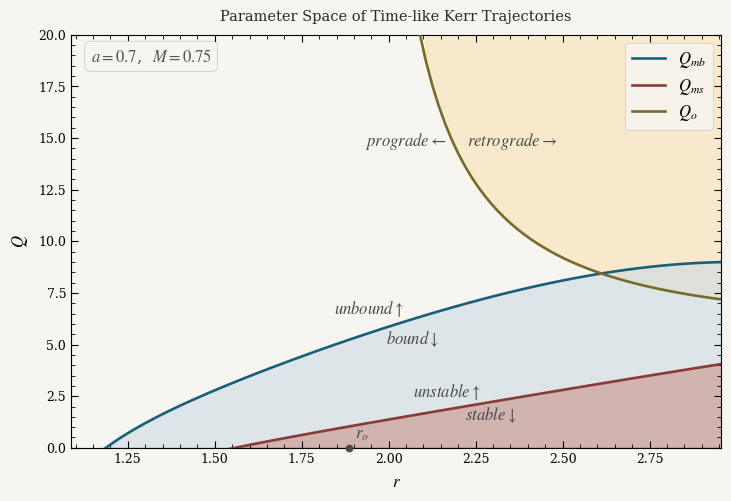

In [6]:
# Parameters
a = 0.7
M = 0.75

# Critical Radii
r1 = 2*M*(1 + np.cos((2/3)*np.arccos(-np.abs(a)/M)))
r2 = 2*M*(1 + np.cos((2/3)*np.arccos( np.abs(a)/M)))
r3 = M + 2*np.sqrt(M**2 - a**2/3) * np.cos((1/3) * np.arccos(M * (M**2 - a**2) / (M**2 - a**2/3)**(3/2)))
ro = M + 2*np.sqrt((3*M**2 - a**2)/3)*np.cos((1/3)*np.arccos(((3*M*(M**2-a**2))/(3*M**2-a**2))*np.sqrt(3/(3*M**2-a**2))))

r = np.linspace(r1, r2, 100)
delta  = r**2 - 2*M*r + a**2

Qo = np.zeros_like(r)


# Quantities
Qms = -(M*r**(5/2)*((np.sqrt(delta) - 2*np.sqrt(M*r))**2 - 4*a**2))/(4*a**2*(r**(3/2) - M*np.sqrt(r) - np.sqrt(M*delta)))

Qmb = -(M*(r**2)*(r*(np.sqrt(r) - 2*np.sqrt(M))**2 - a**2))/(a**2*(np.sqrt(r) - np.sqrt(M))**2)

for id, Radius in enumerate(r):
    if Radius>ro:
        deltaRadius  = Radius**2 - 2*M*Radius + a**2
        Qo[id] = (M*Radius**2*(deltaRadius**2 + 4*M*Radius**2*(Radius-M)))/((Radius**2 + a**2)*(Radius*deltaRadius - M*(Radius**2-a**2)))
    else: 
        Qo[id] = None

fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor=BG)
ax.set_facecolor(BG)
ax.set_title(
    r"Parameter Space of Time-like Kerr Trajectories",
    fontsize=10.5, pad=10, color="#2A2A2A"
)

ax.axhline(y=0, color="#999999", lw=0.9, ls="--", zorder=1)

ax.plot(r, Qmb,   color=COL_TEAL, lw=1.9, label=r"$Q_{mb}$",      zorder=3)
ax.plot(r, Qms,     color=COL_ROSE,   lw=1.9, label=r"$Q_{ms}$", zorder=3)
ax.plot(r, Qo, color=COL_GOLD,  lw=1.9, label=r"$Q_o$",         zorder=3)


ax.set_xlim(r1, r2)
ax.set_ylim(0,20)

# Critical Radii
criticalRadii = [
    (ro,  r"$r_o$",  "right")
]

for r_val, sym, side in criticalRadii:
    ax.plot(r_val, 0, marker='o', ms=4.5,
            color=COL_CHARC, zorder=6, clip_on=False)

    ax.plot([r_val, r_val], [-0.12, 0.12],
            color=COL_CHARC, lw=0.9, ls='--', zorder=5, alpha=0.5)
    xoff = 4 if side == "right" else -4
    ax.annotate(sym, xy=(r_val, 0),
                xytext=(xoff, 10), textcoords="offset points",
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="center")


ax.set_xlabel(r"$r$", fontsize=12, labelpad=6)
ax.set_ylabel(r"$Q$", fontsize=12, labelpad=6)
ax.tick_params(labelsize=9)

legend = ax.legend(fontsize=12.0, framealpha=0.85, edgecolor="#CCCCCC",
                   facecolor=BG, loc="upper right",
                   handlelength=2.0, labelspacing=0.4)
legend.get_frame().set_linewidth(0.6)

param_text = rf"$a = {a}$,  $M = {M}$"
ax.text(0.03, 0.97, param_text,
        transform=ax.transAxes, fontsize=12.0,
        va="top", ha="left", color="#555555",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=BG,
                  edgecolor="#CCCCCC", linewidth=0.6))


ax.fill_between(r, Qms,
                where=(Qmb > 0),
                color=COL_ROSE, alpha=0.35,
                label="Forbidden region", zorder=1)

ax.fill_between(r, Qo , 20,
                where=(Qo < 20),
                color=COL_YELLOW, alpha=0.15,
                label="Forbidden region", zorder=1)

ax.fill_between(r, Qmb, Qms,
                where=(Qmb > Qms),
                color=COL_LBLUE, alpha=0.55,
                label="Forbidden region", zorder=1)

ax.annotate(r"$unbound \uparrow$", xy=(r[40], Qmb[40]*1.25),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

ax.annotate(r"$bound \downarrow$", xy=(r[48], Qmb[48]*0.82),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

ax.annotate(r"$unstable \uparrow$", xy=(r[52], Qms[52]*1.43),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

ax.annotate(r"$stable \downarrow$", xy=(r[60], Qms[60]*0.55),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

ax.annotate(r"$prograde \leftarrow$", xy=(r[60]*0.87, Qo[60]*1.05),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

ax.annotate(r"$retrograde \rightarrow$", xy=(r[60]*1.002, Qo[60]*1.05),
                fontsize=12, color=COL_CHARC,
                ha="left" if side == "right" else "right", va="bottom")

plt.tight_layout(pad=1.4)
plt.savefig("../report/figures/kerr_timelike_parameter_space.png",
            dpi=300, bbox_inches="tight", facecolor=BG)

Computed  E   = 0.7169
Computed  Φ   = 1.4357
w1 = 0.1686   u1 = sqrt(w1) = 0.41062
w2 = 6.1006
Δφ per oscillation = 15.97442


/Users/ye/venv/main/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/ye/venv/main/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


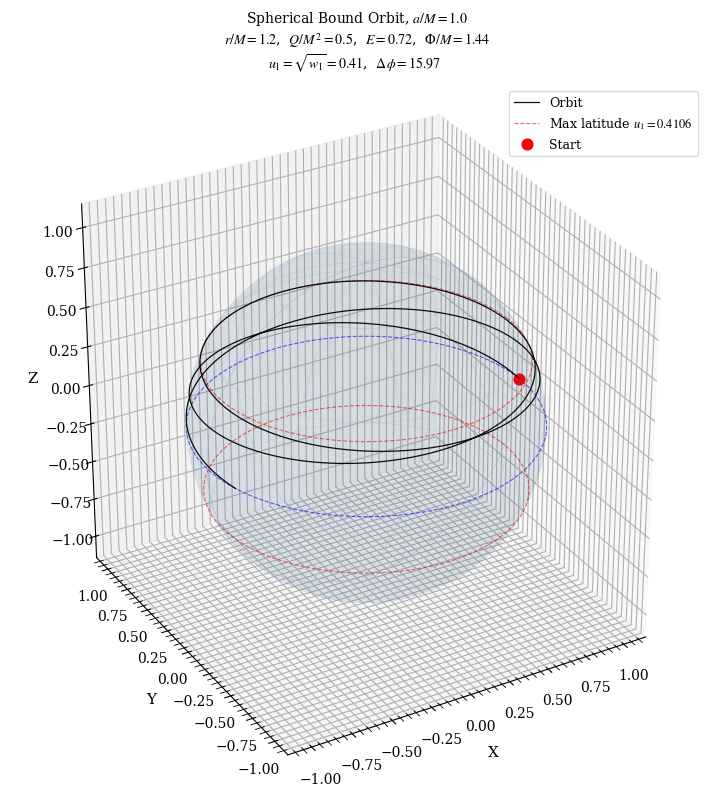

In [7]:
import numpy as np
import matplotlib.pyplot as plt


# Parameters
M = 1.0
a = M          
r = 1.2      
Q = 0.5         

Delta = r**2 - 2*M*r + a**2     

# Calculating Energy and Angular Momentum of the particle at that radius
Upsilon = M*r**5 - Q*(r - 3*M)*r**3 + a**2 * Q**2
sqrt_Upsilon = np.sqrt(Upsilon)
Gamma_a = r**3 * (r - 3*M) - 2*a * (a*Q - sqrt_Upsilon)

denom = r**2 * np.sqrt(Gamma_a)

E   = (r**3 * (r - 2*M) - a * (a*Q - sqrt_Upsilon)) / denom          
Phi = -(2*M*a*r**3 + (r**2 + a**2) * (a*Q - sqrt_Upsilon)) / denom   

print(f"Computed  E   = {E:.4f}")
print(f"Computed  Φ   = {Phi:.4f}")

# Calculating latitudinal roots
coeff = a**2 * (1.0 - E**2)
A     = coeff + Q + Phi**2
disc  = np.sqrt(A**2 - 4.0 * coeff * Q)
w1    = (A - disc) / (2.0 * coeff)   
w2    = (A + disc) / (2.0 * coeff)   

print(f"w1 = {w1:.4f}   u1 = sqrt(w1) = {np.sqrt(w1):.5f}")
print(f"w2 = {w2:.4f}")

# Elliptic Functions
k   = np.sqrt(w1 / w2)          
m   = k**2                     
alp = a * np.sqrt((1.0 - E**2) * w2)   

K_val         = ellipk(m)       
lambda_period = 4.0 * K_val / alp      

n_periods = 0.5       
N_pts     = 12000
lam       = np.linspace(0.0, n_periods * lambda_period, N_pts)

sn_v, cn_v, dn_v, psi_v = ellipj(alp * lam, m)

u_arr     = np.sqrt(w1) * sn_v                     
theta_arr = np.arccos(np.clip(u_arr, -1.0, 1.0))  

# Incomplete elliptic integral of the 3rd kind  Π(ψ, w1, k)
psi_max  = float(psi_v[-1])
N_fine   = 300_000
psi_fine = np.linspace(0.0, psi_max, N_fine)
sin2_f   = np.sin(psi_fine)**2
intgd    = 1.0 / (
    (1.0 - w1 * sin2_f) *
    np.sqrt(np.maximum(1.0 - m * sin2_f, 1e-15))
)
Pi_fine  = np.concatenate([[0.0], cumulative_trapezoid(intgd, psi_fine)])
Pi_arr   = np.interp(psi_v, psi_fine, Pi_fine)   # Π at each λ

drift   = (a / Delta) * (2.0*M*r*E - a*Phi)
phi_arr = (Phi / alp) * Pi_arr + drift * lam

idx_period = np.argmin(np.abs(lam - lambda_period))
delta_phi  = phi_arr[idx_period]
print(f"Δφ per oscillation = {delta_phi:.5f}")

# Cartesian Mapping
X = np.sin(theta_arr) * np.cos(phi_arr)
Y = np.sin(theta_arr) * np.sin(phi_arr)
Z = u_arr   

fig = plt.figure(figsize=(9, 8), facecolor='white')
ax  = fig.add_subplot(111, projection='3d', facecolor='white')

us = np.linspace(0, 2*np.pi, 80)
vs = np.linspace(0, np.pi,   80)
Xs = np.outer(np.cos(us), np.sin(vs))
Ys = np.outer(np.sin(us), np.sin(vs))
Zs = np.outer(np.ones_like(us), np.cos(vs))
ax.plot_surface(Xs, Ys, Zs, alpha=0.07, color='steelblue',
                linewidth=0, zorder=0)

for az in np.linspace(0, np.pi, 6):
    tvals = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.sin(tvals)*np.cos(az), np.sin(tvals)*np.sin(az),
            np.cos(tvals), '-', color='lightsteelblue', lw=0.35, alpha=0.5)
for lat in np.linspace(-np.pi/3, np.pi/3, 5):
    tvals = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(lat)*np.cos(tvals), np.cos(lat)*np.sin(tvals),
            np.sin(lat)*np.ones(200), '-', color='lightsteelblue',
            lw=0.35, alpha=0.5)

# Equator
eq = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(eq), np.sin(eq), np.zeros(300),
        'b--', lw=0.8, alpha=0.6, zorder=2)

# Orbit Path
ax.plot(X, Y, Z, 'k-', lw=0.9, alpha=0.95, zorder=5, label='Orbit')

# Latitude Bounds
u1  = np.sqrt(w1)
lat_circ = np.linspace(0, 2*np.pi, 300)
r_lat    = np.sqrt(1 - u1**2)
ax.plot(r_lat*np.cos(lat_circ), r_lat*np.sin(lat_circ),
         u1*np.ones(300),  'r--', lw=0.8, alpha=0.6)
ax.plot(r_lat*np.cos(lat_circ), r_lat*np.sin(lat_circ),
        -u1*np.ones(300), 'r--', lw=0.8, alpha=0.6,
        label=fr'Max latitude $u_1={u1:.4f}$')

# Starting point
ax.scatter([X[0]], [Y[0]], [Z[0]], color='red', s=60,
           zorder=10, label='Start')

# Observer
ax.view_init(elev=30, azim=-120)
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel('X', fontsize=11, labelpad=6)
ax.set_ylabel('Y', fontsize=11, labelpad=6)
ax.set_zlabel('Z', fontsize=11, labelpad=6)
ax.set_title(
    fr'Spherical Bound Orbit, $a/M = {a/M:.1f}$' + '\n' +
    fr'$r/M = {r:.1f}$,  $Q/M^2 = {Q:.1f}$,  '
    fr'$E = {E:.2f}$,  $\Phi/M = {Phi:.2f}$' + '\n' +
    fr'$u_1 = \sqrt{{w_1}} = {u1:.2f}$,  '
    fr'$\Delta\phi = {delta_phi:.2f}$  ',
    fontsize=10, pad=12
)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../report/figures/kerr_timelike_orbit.png', dpi=300, bbox_inches='tight')